# Image Colorization with CNNs and Conditional GANs

## Overview

This notebook demonstrates an end-to-end image colorization project implemented in PyTorch. The objective is to predict realistic color images from grayscale inputs using deep learning.

The notebook is organized into two complementary parts.

**Part A** investigates image colorization as a supervised regression problem using convolutional encoder–decoder networks and U-Net architectures with skip connections.

**Part B** builds upon these models by implementing a Conditional Generative Adversarial Network (cGAN), where a generator learns to produce realistic color images while a discriminator encourages visually plausible outputs through adversarial training.

Together, these approaches illustrate both reconstruction-based and adversarial methods for image-to-image translation.

Steps:

1. Clean and process the dataset and create greyscale images.
2. Implement and modify an autoencoder architecture.
3. Tune the hyperparameters of an autoencoder.
4. Implement skip connections and other techniques to improve performance.
5. Implement a cGAN and compare with an autoencoder.
6. Improve on the cGAN by trying one of several techniques to enhance training.



# Part A — CNN-Based Image Colorization

In this part we will construct and compare different autoencoder models for the image colourization task.

#### Helper code

Provided are some helper functions for loading and preparing the data. Note that you will need to use the Colab GPU for this assignment.

In [ ]:
"""
Colourization of CIFAR-10 Horses via classification.
"""
import argparse
import math
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import numpy.random as npr
import scipy.misc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable


In [ ]:
######################################################################
# Setup working directory
######################################################################
%mkdir -p /content/a3/
%cd /content/a3


/content/a3


In [ ]:
######################################################################
# Helper functions for loading data
######################################################################
# adapted from
# https://github.com/fchollet/keras/blob/master/keras/datasets/cifar10.py

import os
import pickle
import sys
import tarfile

import numpy as np
from PIL import Image
from six.moves.urllib.request import urlretrieve


def get_file(fname, origin, untar=False, extract=False, archive_format="auto", cache_dir="data"):
    datadir = os.path.join(cache_dir)
    if not os.path.exists(datadir):
        os.makedirs(datadir)

    if untar:
        untar_fpath = os.path.join(datadir, fname)
        fpath = untar_fpath + ".tar.gz"
    else:
        fpath = os.path.join(datadir, fname)

    print("File path: %s" % fpath)
    if not os.path.exists(fpath):
        print("Downloading data from", origin)

        error_msg = "URL fetch failure on {}: {} -- {}"
        try:
            try:
                urlretrieve(origin, fpath)
            except URLError as e:
                raise Exception(error_msg.format(origin, e.errno, e.reason))
            except HTTPError as e:
                raise Exception(error_msg.format(origin, e.code, e.msg))
        except (Exception, KeyboardInterrupt) as e:
            if os.path.exists(fpath):
                os.remove(fpath)
            raise

    if untar:
        if not os.path.exists(untar_fpath):
            print("Extracting file.")
            with tarfile.open(fpath) as archive:
                archive.extractall(datadir)
        return untar_fpath

    if extract:
        _extract_archive(fpath, datadir, archive_format)

    return fpath


def load_batch(fpath, label_key="labels"):
    """Internal utility for parsing CIFAR data.
    # Arguments
        fpath: path the file to parse.
        label_key: key for label data in the retrieve
            dictionary.
    # Returns
        A tuple `(data, labels)`.
    """
    f = open(fpath, "rb")
    if sys.version_info < (3,):
        d = pickle.load(f)
    else:
        d = pickle.load(f, encoding="bytes")
        # decode utf8
        d_decoded = {}
        for k, v in d.items():
            d_decoded[k.decode("utf8")] = v
        d = d_decoded
    f.close()
    data = d["data"]
    labels = d[label_key]

    data = data.reshape(data.shape[0], 3, 32, 32)
    return data, labels


def load_cifar10(transpose=False):
    """Loads CIFAR10 dataset.
    # Returns
        Tuple of Numpy arrays: `(x_train, y_train), (x_test, y_test)`.
    """
    dirname = "cifar-10-batches-py"
    origin = "http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
    path = get_file(dirname, origin=origin, untar=True)

    num_train_samples = 50000

    x_train = np.zeros((num_train_samples, 3, 32, 32), dtype="uint8")
    y_train = np.zeros((num_train_samples,), dtype="uint8")

    for i in range(1, 6):
        fpath = os.path.join(path, "data_batch_" + str(i))
        data, labels = load_batch(fpath)
        x_train[(i - 1) * 10000 : i * 10000, :, :, :] = data
        y_train[(i - 1) * 10000 : i * 10000] = labels

    fpath = os.path.join(path, "test_batch")
    x_test, y_test = load_batch(fpath)

    y_train = np.reshape(y_train, (len(y_train), 1))
    y_test = np.reshape(y_test, (len(y_test), 1))

    if transpose:
        x_train = x_train.transpose(0, 2, 3, 1)
        x_test = x_test.transpose(0, 2, 3, 1)
    return (x_train, y_train), (x_test, y_test)

In [ ]:
# Download CIFAR dataset
m = load_cifar10()

File path: data/cifar-10-batches-py.tar.gz
Extracting file.


## Part 1. Data Preparation 

To start off run the above code to load the CIFAR dataset and then work through the following questions/tasks.

### Part (a)
Verify that the dataset has loaded correctly. How many samples do we have? How is the data organized?




$\color{blue}{\text{Answer: }}$  


- <font color=Blue>The data has been loaded correctly. The data has been loaded in a tuple with two groups: train and test set. <font color=black>
- <font color=Blue> train and test set are tuple with lenght of two: one for  images with their pixels and one for labels <font color=black>

- <font color=Blue> We have 50000 images with their labels in train set. We have 10 groups of images<font color=black>


- <font color=Blue> We have 10000 images with their labels in test set.<font color=black>

- <font color=Blue> We have 50000 RBG images with 32*32 pixels and label of every image has been loaded as numpy.ndarray.<font color=black>


- <font color=Blue> We have 10000 RBG images with 32*32 pixels and label of every image has been loaded.<font color=black>



In [ ]:
print('type of the data:',type(m))
print('length of data with tuple type=',len(m))
train, test= m
print('type of the train set:', type(train))
print('length of train set with tuple type', len(train))

print('type of the test set:', type(test))
print('length of test set with tuple type', len(test))
x_train, train_label=train
x_test, test_label=test
print('type of the x_train set:', type(x_train))
print('Shape of the training images as numpy.ndarray:', x_train.shape)
print('Shape of the training images as numpy.ndarray:', x_test.shape)

print('Number of images in train set=', len(x_train))
print('Number of labels in train set=', len(train_label))
print('Number of images in test set=', len(x_test))
print('Number of labels in test set=', len(test_label))

len(np.unique(test_label, axis=0))


type of the data: <class 'tuple'>
length of data with tuple type= 2
type of the train set: <class 'tuple'>
length of train set with tuple type 2
type of the test set: <class 'tuple'>
length of test set with tuple type 2
type of the x_train set: <class 'numpy.ndarray'>
Shape of the training images as numpy.ndarray: (50000, 3, 32, 32)
Shape of the training images as numpy.ndarray: (10000, 3, 32, 32)
Number of images in train set= 50000
Number of labels in train set= 50000
Number of images in test set= 10000
Number of labels in test set= 10000


10

### Part (b) 
Preprocess the data to select only images of horses. Learning to generate only hourse images will make our task easier. Your function will also convert the colour images to greyscale to create our input data.

In [ ]:
# select a single category.
HORSE_CATEGORY = 7

# convert colour images into greyscale
def process(xs, ys, max_pixel=256.0, downsize_input=False):
    """
    Pre-process CIFAR10 images by taking only the horse category,
    shuffling, and have colour values be bound between 0 and 1

    Args:
      xs: the colour RGB pixel values
      ys: the category labels
      max_pixel: maximum pixel value in the original data
    Returns:
      xs: value normalized and shuffled colour images
      grey: greyscale images, also normalized so values are between 0 and 1
    """
    xs = xs / max_pixel
    xs = xs[np.where(ys == HORSE_CATEGORY)[0], :, :, :]
    npr.shuffle(xs)

    grey = np.mean(xs, axis=1, keepdims=True)

    if downsize_input:
        downsize_module = nn.Sequential(
            nn.AvgPool2d(2),
            nn.AvgPool2d(2),
            nn.Upsample(scale_factor=2),
            nn.Upsample(scale_factor=2),
        )
        xs_downsized = downsize_module.forward(torch.from_numpy(xs).float())
        xs_downsized = xs_downsized.data.numpy()
        return (xs, xs_downsized)
    else:
        return (xs, grey)


### Part (c)
Create a dataloader (or function) to batch the samples.

In [ ]:
# dataloader for batching samples

def get_batch(x, y, batch_size):
    """
    Generated that yields batches of data

    Args:
      x: input values
      y: output values
      batch_size: size of each batch
    Yields:
      batch_x: a batch of inputs of size at most batch_size
      batch_y: a batch of outputs of size at most batch_size
    """
    N = np.shape(x)[0]
    assert N == np.shape(y)[0]
    for i in range(0, N, batch_size):
        batch_x = x[i : i + batch_size, :, :, :]
        batch_y = y[i : i + batch_size, :, :, :]
        yield (batch_x, batch_y)

### Part (e) 
Verify and visualize that we are able to generate different batches of data.

In [ ]:
# code to load different batches of horse dataset

print("Loading data...")
(x_train, y_train), (x_test, y_test) = load_cifar10()

print("Transforming data...")
train_rgb, train_grey = process(x_train, y_train)
test_rgb, test_grey = process(x_test, y_test)


Loading data...
File path: data/cifar-10-batches-py.tar.gz
Transforming data...


In [ ]:
# shape of data and labels before selection
print(x_train.shape, y_train.shape)

(50000, 3, 32, 32) (50000, 1)


In [ ]:
# shape of training data
print('Training Data: ', train_rgb.shape, train_grey.shape)
# shape of testing data
print('Testing Data: ', test_rgb.shape, test_grey.shape)

Training Data:  (5000, 3, 32, 32) (5000, 1, 32, 32)
Testing Data:  (1000, 3, 32, 32) (1000, 1, 32, 32)


<font color=Blue>Load Batches<font color=Blue>

In [ ]:
# obtain batches of images
xs, ys = next(iter(get_batch(train_grey, train_rgb, 10)))
print(xs.shape, ys.shape)

(10, 1, 32, 32) (10, 3, 32, 32)


Visualization



$\color{blue}{\text{ }}$  


- <font color=Blue>5 images in train set with corresponding gray images has been ploted <font color=black>

- <font color=Blue>5 images in test set with corresponding gray images has been ploted <font color=black>

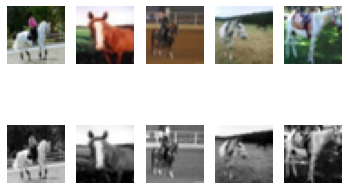

In [ ]:
# visualize 5 train/test images
import matplotlib.pyplot as plt

k = 0
for images in train_rgb:
    image = images
    # place the colour channel at the end, instead of at the beginning
    img = np.transpose(image, [1,2,0])
    plt.subplot(2, 5, k+1)
    plt.axis('off')
    plt.imshow(img)

    k += 1
    if k > 4:
        break


for images in train_grey:
    image = images
    # place the colour channel at the end, instead of at the beginning
    img = np.transpose(image, [1,2,0])
    plt.subplot(2, 5, k+1)
    plt.axis('off')
    plt.imshow(img[:,:,0], cmap='gray')

    k += 1
    if k > 9:
        break


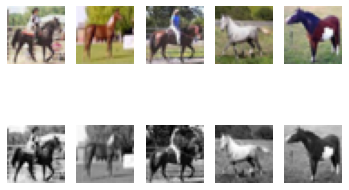

In [ ]:
k = 0
for images in test_rgb:
    image = images
    # place the colour channel at the end, instead of at the beginning
    img = np.transpose(image, [1,2,0])
    plt.subplot(2, 5, k+1)
    plt.axis('off')
    plt.imshow(img)

    k += 1
    if k > 4:
        break


for images in test_grey:
    image = images
    # place the colour channel at the end, instead of at the beginning
    img = np.transpose(image, [1,2,0])
    plt.subplot(2, 5, k+1)
    plt.axis('off')
    plt.imshow(img[:,:,0],cmap='gray')

    k += 1
    if k > 9:
        break

## Part 2. Colourization as Regression 

There are many ways to frame the problem of image colourization as a machine learning problem. One naive approach is to frame it as a regression problem, where we build a model to predict the RGB intensities at each pixel given the greyscale input. In this case, the outputs are continuous, and so squared error can be used to train the model.

In this section, you will get familar with training neural networks using cloud GPUs. Run the helper code and answer the questions that follow.

#### Helper Code

Regression Architecture

In [ ]:
class RegressionCNN(nn.Module):
    def __init__(self, kernel, num_filters):
        # first call parent's initialization function
        super().__init__()
        padding = kernel // 2

        self.downconv1 = nn.Sequential(
            nn.Conv2d(1, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),)
        self.downconv2 = nn.Sequential(
            nn.Conv2d(num_filters, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2),)

        self.rfconv = nn.Sequential(
            nn.Conv2d(num_filters*2, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU())

        self.upconv1 = nn.Sequential(
            nn.Conv2d(num_filters*2, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),)
        self.upconv2 = nn.Sequential(
            nn.Conv2d(num_filters, 3, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),)
        self.finalconv = nn.Conv2d(3, 3, kernel_size=kernel, padding=padding)

    def forward(self, x):
        out = self.downconv1(x)
        out = self.downconv2(out)
        out = self.rfconv(out)
        out = self.upconv1(out)
        out = self.upconv2(out)
        out = self.finalconv(out)
        return out

<font color=blue>  Compute loss <font color=blue>

In [ ]:
def get_loss(gen,  batch_size,):
  criterion = nn.MSELoss()
  losses = []
  for i, (xs, ys) in enumerate(get_batch(test_grey, test_rgb, args.batch_size)):
      images, labels = get_torch_vars(xs, ys, args.gpu)
      outputs = gen(images)
      loss = criterion(outputs, labels)
      losses.append(loss.data.item())
  Test_loss=np.mean(losses)
  return Test_loss

Training code

In [ ]:
class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

def get_torch_vars(xs, ys, gpu=False):
    """
    Helper function to convert numpy arrays to pytorch tensors.
    If GPU is used, move the tensors to GPU.

    Args:
      xs (float numpy tenosor): greyscale input
      ys (int numpy tenosor): rgb as labels
      gpu (bool): whether to move pytorch tensor to GPU
    Returns:
      Variable(xs), Variable(ys)
    """
    xs = torch.from_numpy(xs).float()
    ys = torch.from_numpy(ys).float()
    if gpu:
        xs = xs.cuda()
        ys = ys.cuda()
    return Variable(xs), Variable(ys)

def train(args, gen=None):

    # Numpy random seed
    npr.seed(args.seed)

    # Save directory
    save_dir = "outputs/" + args.experiment_name

    # LOAD THE MODEL
    if gen is None:
        Net = globals()[args.model]
        gen = Net(args.kernel, args.num_filters)

    # LOSS FUNCTION
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(gen.parameters(), lr=args.learn_rate)

    # DATA
    print("Loading data...")
    (x_train, y_train), (x_test, y_test) = load_cifar10()

    print("Transforming data...")
    train_rgb, train_grey = process(x_train, y_train, downsize_input=args.downsize_input)
    test_rgb, test_grey = process(x_test, y_test, downsize_input=args.downsize_input)

    # Create the outputs folder if not created already
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    print("Beginning training ...")
    if args.gpu:
        gen.cuda()
    start = time.time()

    train_losses = []
    valid_losses = []
    valid_accs = []
    for epoch in range(args.epochs):
        # Train the Model
        gen.train()  # Change model to 'train' mode
        losses = []
        for i, (xs, ys) in enumerate(get_batch(train_grey, train_rgb, args.batch_size)):
            images, labels = get_torch_vars(xs, ys, args.gpu)
            # Forward + Backward + Optimize
            optimizer.zero_grad()
            outputs = gen(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            losses.append(loss.data.item())

        print(epoch, loss.cpu().detach())

        train_losses.append(np.mean(losses))  # compute Train loss
        valid_losses.append(get_loss(gen, args.batch_size))  # compute Test loss
        if args.plot:
          visual(images, labels, outputs, args.gpu, 1)

    print("final train loss=", np.mean(losses) )
    print("final test loss=", get_loss(gen, args.batch_size))
    x = len(valid_losses)
    plt.title("Train vs Test Loss")
    plt.plot(range(1,x+1), train_losses, label="Train")
    plt.plot(range(1,x+1), valid_losses, label="Test")
    plt.xlabel("epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    return gen

Training visualization code

In [ ]:
# visualize 5 train/test images
def visual(img_grey, img_real, img_fake, gpu = 0, flag_torch = 0):

  if gpu:
    img_grey = img_grey.cpu().detach()
    img_real = img_real.cpu().detach()
    img_fake = img_fake.cpu().detach()

  if flag_torch:
    img_grey = img_grey.numpy()
    img_real = img_real.numpy()
    img_fake = img_fake.numpy()

  if flag_torch == 2:
    img_real = np.transpose(img_real[:, :, :, :, :], [0, 4, 2, 3, 1]).squeeze()
    img_fake = np.transpose(img_fake[:, :, :, :, :], [0, 4, 2, 3, 1]).squeeze()

  #correct image structure
  img_grey = np.transpose(img_grey[:5, :, :, :], [0, 2, 3, 1]).squeeze()
  img_real = np.transpose(img_real[:5, :, :, :], [0, 2, 3, 1])
  img_fake = np.transpose(img_fake[:5, :, :, :], [0, 2, 3, 1])


  for i in range(5):
      ax = plt.subplot(3, 5, i + 1)
      ax.imshow(img_grey[i], cmap='gray')
      ax.axis("off")
      ax = plt.subplot(3, 5, i + 1 + 5)
      ax.imshow(img_real[i])
      ax.axis("off")
      ax = plt.subplot(3, 5, i + 1 + 10)
      ax.imshow(img_fake[i])
      ax.axis("off")
  plt.show()

Main training loop for regression CNN

In [ ]:
#Main training loop for CNN
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "RegressionCNN",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 100,
    "epochs": 25,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}

args.update(args_dict)
cnn = train(args)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Show 5 pics from test set:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


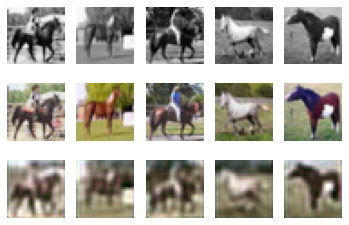

In [ ]:
print("Show 5 pics from test set:")
k = 0
for  i, (xs, ys) in enumerate(get_batch(test_grey, test_rgb, args.batch_size)):
    images, labels = get_torch_vars(xs, ys, args.gpu)
    outputs = cnn(images)
    visual(images, labels, outputs, args.gpu, 1)
    k += 1
    if k > 0:
        break


### Part (a)
Describe the model RegressionCNN. How many convolution layers does it have? What are the filter sizes and number of filters at each layer? Construct a table or draw a diagram.

$\color{blue}{\text{}}$  


- <font color=Blue>We have 6 convolution layers in the architecture <font color=black>


<font color=Blue>

 |Layer # | number of input channel | Number of filters| filter size| description  |
:-------------------|:---------------:|--------------------:|--------------------:|--------------------:
First layer|  1|32|3*3| There is a BatchNorm2d - Relu - and maxpool2d after the convolution layer |
Second layer|  32|64|3*3|  There is a BatchNorm2d - Relu - and maxpool2d after the convolution layer |
Third layer|  64|64|3*3|  There is a BatchNorm2d - and  Relu after the convolution layer |
Fourth layer|  64|32|3*3|  There is a BatchNorm2d -  Relu - and Upsample after the convolution layer |
Fifth layer|  32|3|3*3|  There is a BatchNorm2d -   Relu - and Upsample after the convolution layer |
Sixth layer|  3|3|3*3|  - |

<font color=Blue>

### Part (b)
Run the regression training code (should run without errors). This will generate some images. How many epochs are we training the CNN model in the given setting?

$\color{Blue}{\text{ }}$  


- <font color=Blue> We are training the CNN model in the given setting for 25 epochs <font color=black>

### Part (c)
Re-train a couple of new models using a different number of training epochs. You may train each new models in a new code cell by copying and modifying the code from the last notebook cell. Comment on how the results (output images, training loss) change as we increase or decrease the number of epochs.

$\color{blue}{\text{ }}$  





- <font color=blue>By increasing  epoch the quality and predicted color of images will increase slightly and color of predicted images would be closer to the images' color. Moreover, the training loss would decrease. For example, when epoch is 100 training loss=0.0055 that is less than  0.0088 for epoch=25.  <font color=black>


- <font color=blue>By decreasing epoch the quality and predicted color of images will decrease. Moreover, the training loss would increase. For example, when epoch is 12 training loss=0.01 that is more than  0.0088 when epoch=25.  
when epoch is 3 the color would not be predicted at all and training loss is so high.
<font color=black>



In [ ]:
#Main training loop for CNN
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "RegressionCNN",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 100,
    "epochs": 50,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}

args.update(args_dict)
cnn = train(args)

In [ ]:
#Main training loop for CNN
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "RegressionCNN",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 100,
    "epochs": 100,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}

args.update(args_dict)
cnn = train(args)

In [ ]:
#Main training loop for CNN
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "RegressionCNN",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 100,
    "epochs": 12,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}

args.update(args_dict)
cnn = train(args)

In [ ]:
#Main training loop for CNN
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "RegressionCNN",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 100,
    "epochs": 8,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}

args.update(args_dict)
cnn = train(args)

In [ ]:
#Main training loop for CNN
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "RegressionCNN",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 100,
    "epochs": 3,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}

args.update(args_dict)
cnn = train(args)

## Part 3. Skip Connections
A skip connection in a neural network is a connection which skips one or more layer and connects to a later layer. We will introduce skip connections.

### Part (a) 
Add a skip connection from the first layer to the last, second layer to the second last, etc.
That is, the final convolution should have both the output of the previous layer and the initial greyscale input as input. This type of skip-connection is introduced by [3], and is called a "UNet". Following the CNN class that you have completed, complete the __init__ and forward methods of the UNet class.
Hint: You will need to use the function torch.cat.

In [ ]:
#complete the code

class UNet(nn.Module):
    def __init__(self, kernel, num_filters, num_colours=3, num_in_channels=1):
        super().__init__()

        # Useful parameters
        stride = 2
        padding = kernel // 2
        output_padding = 1

        ############### YOUR CODE GOES HERE ###############
        ###################################################
        self.downconv1 = nn.Sequential(
            nn.Conv2d(num_in_channels, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),)
        self.downconv2 = nn.Sequential(
            nn.Conv2d(num_filters, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2),)

        self.rfconv = nn.Sequential(
            nn.Conv2d(num_filters*2, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU())

        self.upconv1 = nn.Sequential(
            nn.Conv2d(num_filters*4, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),)
        self.upconv2 = nn.Sequential(
            nn.Conv2d(num_filters*2, num_colours, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_colours),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),)
        self.finalconv = nn.Conv2d(num_colours+num_in_channels, 3, kernel_size=kernel, padding=padding)




    def forward(self, x):
        ############### YOUR CODE GOES HERE ###############
        ###################################################
        L1 = self.downconv1(x)
        L2 = self.downconv2(L1)
        L3 = self.rfconv(L2)
        L4 = self.upconv1( torch.cat((L3, L2), dim=1))
        L5 = self.upconv2(torch.cat((L4, L1), dim=1))
        L6 = self.finalconv(torch.cat((L5, x), dim=1))


        return L6

### Part (b) 
Train the "UNet" model for the same amount of epochs as the previous CNN and plot the training curve using a batch size of 100. How does the result compare to the previous model? Did skip connections improve the validation loss and accuracy? Did the skip connections improve the output qualitatively? How? Give at least two reasons why skip connections might improve the performance of our CNN models.




$\color{blue}{\text{ }}$  



- <font color=Blue> The resuts of this model is better than the results of the previous CNN. <font color=black>


- <font color=Blue>The results has been improved because of skip connection. <font color=black>

- <font color=Blue>Training and test loss have been decreased: <font color=black>

- <font color=Blue>The model for this part didn't overfit. <font color=black>


<font color=Blue>

 | | The model with skip connection| The previous CNN|
:-------------------|:---------------:|--------------------:
train loss|  0.0055| 0.00559|
test loss|  0.00557|0.00655|
<font color=black>


$\color{blue}{\text{two reasons : }}$  

- <font color=Blue>The quality of images have been increased because of skip connection as it help with vanishing gradient problem.<font color=black>

- <font color=blue>keeping some information from previous layer will help to use information that has been forgotten. So, it makes sure that information is not lost. Moreover, by using skip connection the value of loss will decrease.<font color=black>



In [ ]:
# Main training loop for UNet
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "UNet",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 100,
    "epochs": 25,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}
args.update(args_dict)
cnn = train(args)

### Part (c)
Re-train a few more "UNet" models using different mini batch sizes with a fixed number of epochs. Describe the effect of batch sizes on the training/validation loss, and the final image output.




$\color{blue}{\text{}}$  


- <font color=blue>By increasing batch size (`batch size=200`) The quality of images will decrease <font color=black>

- <font color=blue>By decreasing batch size (`batch size=25`) the quality of predicted images increase and loss value will decrease.<font color=black>


- <font color=blue>By too much decreasing batch size (`batch size=5`) the model overfit. The quality of images in train set would be so good, but the quality of images in test set will not increase. <font color=black>

In [ ]:
# complete the code

# Main training loop for UNet
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "UNet",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 200,
    "epochs": 25,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}
args.update(args_dict)
cnn = train(args)






In [ ]:
# complete the code

# Main training loop for UNet
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "UNet",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 400,
    "epochs": 25,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}
args.update(args_dict)
cnn = train(args)






In [ ]:
# Main training loop for UNet
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "UNet",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 50,
    "epochs": 25,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}
args.update(args_dict)
cnn = train(args)

In [ ]:
# Main training loop for UNet
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "UNet",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 25,
    "epochs": 25,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}
args.update(args_dict)
cnn = train(args)

In [ ]:
# Main training loop for UNet
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "UNet",
    "kernel": 3,
    "num_filters": 32,
    'learn_rate':0.001,
    "batch_size": 5,
    "epochs": 25,
    "seed": 0,
    "plot": True,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}
args.update(args_dict)
cnn = train(args)

In [ ]:
print("Show 5 pics from test set:")
k = 0
for  i, (xs, ys) in enumerate(get_batch(test_grey, test_rgb, args.batch_size)):
    images, labels = get_torch_vars(xs, ys, args.gpu)
    outputs = cnn(images)
    visual(images, labels, outputs, args.gpu, 1)
    k += 1
    if k > 0:
        break

# PART B - Conditional GAN 

In this second half of the assignment we will construct a conditional generative adversarial network for our image colourization task.

## Part 1. Conditional GAN 
To start we will be modifying the previous sample code to construct and train a conditional GAN. We will exploring the different architectures to identify and select our best image colourization model.

Note: This second half of the assignment should be started after the lecture on generative adversarial networks (GANs).


### Part (a)
Modify the provided training code to implement a generator. Then test to verify it works on the desired input (Hint: you can reuse some of your earlier autoencoder models here to act as a generator)




$\color{blue}{\text{ }}$  


- <font color=blue>I will use the archtecture of Skip connection that we had. <font color=black>


In [ ]:
class Generator(nn.Module):
    def __init__(self, kernel, num_filters, num_colours=3, num_in_channels=1):
        super().__init__()

        # Useful parameters
        stride = 2
        padding = kernel // 2
        output_padding = 1

        ############### YOUR CODE GOES HERE ###############
        ###################################################
        self.downconv1 = nn.Sequential(
            nn.Conv2d(num_in_channels, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),)
        self.downconv2 = nn.Sequential(
            nn.Conv2d(num_filters, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2),)

        self.rfconv = nn.Sequential(
            nn.Conv2d(num_filters*2, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU())

        self.upconv1 = nn.Sequential(
            nn.Conv2d(num_filters*4, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),)
        self.upconv2 = nn.Sequential(
            nn.Conv2d(num_filters*2, num_colours, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_colours),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),)
        self.finalconv = nn.Conv2d(num_colours+num_in_channels, 3, kernel_size=kernel, padding=padding)




    def forward(self, x):
        ############### YOUR CODE GOES HERE ###############
        ###################################################
        L1 = self.downconv1(x)
        L2 = self.downconv2(L1)
        L3 = self.rfconv(L2)
        L4 = self.upconv1( torch.cat((L3, L2), dim=1))
        L5 = self.upconv2(torch.cat((L4, L1), dim=1))
        out = self.finalconv(torch.cat((L5, x), dim=1))
        #out=torch.cat((x, L6), dim=1)



        return out



In [ ]:
#test generator architecture

model=Generator(3,32)
model.cuda()
(x_train, y_train), (x_test, y_test) = load_cifar10()
train_rgb, train_grey = process(x_train, y_train, downsize_input=False)
(xs, ys) = next(iter(get_batch(train_grey, train_rgb, batch_size=100)))
images, labels = get_torch_vars(xs, ys,  gpu=True)
outputs = model(images)
print(outputs.shape)

File path: data/cifar-10-batches-py.tar.gz
torch.Size([100, 3, 32, 32])


### Part (b)
Modify the provided training code to implement a discriminator. Then test to verify it works on the desired input.



$\color{blue}{\text{ }}$  


- <font color=blue>I will use encode parts of the skip connection with several leanir layer as discriminator. <font color=black>

In [ ]:
# discriminator code

class Discriminator(nn.Module):
    def __init__(self, kernel, num_filters, num_colours=3, num_in_channels=1):
        super().__init__()

        # Useful parameters
        stride = 2
        padding = kernel // 2
        output_padding = 1

        ############### YOUR CODE GOES HERE ###############
        ###################################################

        self.downconv1 = nn.Sequential(
            nn.Conv2d(3, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),)
        self.downconv2 = nn.Sequential(
            nn.Conv2d(num_filters, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2),)

        self.rfconv = nn.Sequential(
            nn.Conv2d(num_filters*2, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU())
        self.fc1=nn.Linear(3072, 1024)
        self.act2=nn.LeakyReLU(0.2, inplace=True)
        self.dropout=nn.Dropout(0.3)
        self.fc2=nn.Linear(1024, 64)
        self.fc3=nn.Linear(64, 32)
        self.fc4=nn.Linear(32, 1)
        self.act3=nn.Sigmoid()

    def forward(self, x, img_greyscale):         ### def forward(self, x, img_greyscale):

        ############### YOUR CODE GOES HERE ###############
        # ###################################################
        L1 = self.downconv1(x)
        L2 = self.downconv2(L1)
        x = self.rfconv(L2)

        x = x.view(x.size(0), -1)
        # print(x.shape)
        c = img_greyscale.view(img_greyscale.size(0),-1)
        x = torch.cat([x, c], 1)
        x=self.fc1(x)
        x=self.act2(x)
        x=self.dropout(x)
        x=self.fc2(x)
        x=self.act2(x)
        x=self.dropout(x)
        x=self.fc3(x)
        x=self.act2(x)
        x=self.dropout(x)
        x=self.fc4(x)
        out=self.act3(x)



        return out.squeeze() # Flatten to [batch_size]




In [ ]:
# test discriminator architecture
import torch.nn as nn

model=Discriminator(3,16)
model.cuda()
(x_train, y_train), (x_test, y_test) = load_cifar10()
train_rgb, train_grey = process(x_train, y_train, downsize_input=False)
(xs, ys) = next(iter(get_batch(train_grey, train_rgb, batch_size=50)))
images, labels = get_torch_vars(xs, ys,  gpu=True)
outputs = model(labels, images)
print(outputs.shape)



File path: data/cifar-10-batches-py.tar.gz
torch.Size([50])


### Part (c)
Modify the provided training code to implement a conditional GAN.



$\color{blue}{\text{}}$  


- <font color=blue>has been done <font color=black>

In [ ]:
class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

def get_torch_vars(xs, ys, gpu=False):
    """
    Helper function to convert numpy arrays to pytorch tensors.
    If GPU is used, move the tensors to GPU.

    Args:
      xs (float numpy tenosor): greyscale input
      ys (int numpy tenosor): categorical labels
      gpu (bool): whether to move pytorch tensor to GPU
    Returns:
      Variable(xs), Variable(ys)
    """
    xs = torch.from_numpy(xs).float()
    ys = torch.from_numpy(ys).float() #--> ADDED for cGAN
    if gpu:
        xs = xs.cuda()
        ys = ys.cuda()
    return Variable(xs), Variable(ys)

def train(args, cnn=None):
    # Set the maximum number of threads to prevent crash in Teaching Labs
    # TODO: necessary?
    torch.set_num_threads(5)
    # Numpy random seed
    npr.seed(args.seed)

    # Save directory
    save_dir = "outputs/" + args.experiment_name

    # LOAD THE COLOURS CATEGORIES

    # INPUT CHANNEL
    num_in_channels = 1 if not args.downsize_input else 3
    # LOAD THE MODEL
    if cnn is None:
        Net = globals()[args.model]
        cnn =Generator(args.kernel,args.num_filters)
        discriminator = Discriminator (args.kernel,args.num_filters)


    # LOSS FUNCTION

    criterion = nn.BCELoss()
    g_optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-4)
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

    # DATA
    print("Loading data...")
    (x_train, y_train), (x_test, y_test) = load_cifar10()

    print("Transforming data...")
    train_rgb, train_grey = process(x_train, y_train, downsize_input=args.downsize_input)
    test_rgb, test_grey = process(x_test, y_test, downsize_input=args.downsize_input)

    # Create the outputs folder if not created already
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    print("Beginning training ...")
    if args.gpu:
        cnn.cuda()
        discriminator.cuda()
    start = time.time()

    train_losses = []
    valid_losses = []
    valid_accs = []
    for epoch in range(args.epochs):
        # Train the Model
        cnn.train()
        discriminator.train()
        losses = []

        for i, (xs, ys) in enumerate(get_batch(train_grey, train_rgb, args.batch_size)):
            images, labels = get_torch_vars(xs, ys, args.gpu)

            #--->ADDED 5
            img_grey = images
            img_real = labels
            batch_size = args.batch_size

            #discriminator training
            d_optimizer.zero_grad()
            real_prob = discriminator(img_real,img_grey)
            real_labels=Variable(torch.ones(batch_size)).cuda()
            real_loss = criterion(real_prob, real_labels)
            fake_images = cnn(img_grey)
            fake_prob = discriminator(fake_images, img_grey)
            fake_labels=Variable(torch.zeros(batch_size)).cuda()
            fake_loss = criterion(fake_prob, fake_labels)
            d_loss = real_loss + fake_loss
            d_loss.backward()
            d_optimizer.step()

            # generator training
            g_optimizer.zero_grad()
            fake_images = cnn(img_grey)
            make_real = discriminator(fake_images, img_grey)
            g_loss= criterion(make_real, real_labels)
            g_loss.backward()
            g_optimizer.step()


        # print and visualize
        print(epoch, g_loss.cpu().detach(), d_loss.cpu().detach())
        visual(images, labels, fake_images, args.gpu, 1)

    return cnn

### Part (d)
Train a conditional GAN for image colourization.

In [ ]:
args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "Generator",
    "kernel": 3,
    "num_filters": 16,
    'learn_rate':0.001,
    "batch_size": 50,
    "epochs": 125,
    "seed": 0,
    "plot": False,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}
args.update(args_dict)
cnn = train(args)

#batch size of 50 with 100 epochs seamed to work

### Part (e)
How does the performance of the cGAN compare with the autoencoder models that you tested in the first half of this assignment?



$\color{blue}{\text{ }}$  


- <font color=blue>The cGAN outperforms the autoencoder models we previously evaluated. This method works better because we have a generator(skip conection architecture and a discriminator that improve the preformance of the generator by optimizing its loss function.The quality of images have increased and colors are closer to real ones. <font color=black>


### Part (f) 
A colour space is a choice of mapping of colours into three-dimensional coordinates. Some colours could be close together in one colour space, but further apart in others. The RGB colour space is probably the most familiar to you, the model used in in our regression colourization example computes squared error in RGB colour space. But, most state of the art colourization models
do not use RGB colour space. How could using the RGB colour space be problematic? Your answer should relate how human perception of colour is different than the squared distance. You may use the Wikipedia article on colour space to help you answer the question.


$\color{blue}{\text{ }}$  


- <font color=blue>Color perception is handled by cones and rods, which are photoreceptors.  Rods are responsible for vision at low light levels (scotopic vision). They do not mediate color vision, and have a low spatial acuity. Cones are active at higher light levels (photopic vision), are capable of color vision and are responsible for high spatial acuity.<font color=black>
- <font color=blue>We are not equally sensitive to all of those colours; for example, green light is more sensitive than blue or red light. So, we lose a corresponding sensitivity to the shades of green. This means that if we were to implement RGB colour space, this could be problematic because we are only accounting for the kind of light that is emitted, and so the squared distance between changing the hue of green with a variation of x for example, versus changing hue of red with a same variation of x would give us the same squared distance, but could be preceived by humans differently. Also, RGB could be problematic because it does not take into account the lightness of an image.<font color=black>



## Part 2. Exploration 

At this point we have trained a few different generative models for our image colourization task with varying results. What makes this work exciting is that there many other approaches we could take. In this part of the assignment you will be exploring at least one of several approaches towards improving our performance on the image colourization task. Some well known approaches you can consider include:

- lab colour space representation instead of RBG which simplifies the problem and requires you to predict two output channels instead of three
- k-means to represent RBG colourspace by 'k' distinct colours, this effectively changes the problem from regression to classification.

Other interesting approaches include:
- combining L1 loss along with the discriminator-based loss
- starting with a pretrained generator (i.e. Resnet)
- patch discriminator trained on local regions

A great example of some of these different approaches can be found in a <a href="https://towardsdatascience.com/colorizing-black-white-images-with-u-net-and-conditional-gan-a-tutorial-81b2df111cd8">blog post by Moein Shariatnia</a>.

Note you are only required to pick one of the suggested modifications.

$\color{blue}{\text{Answer: }}$  


- <font color=blue>The first approach has been choosen for improving the quality of images. After using this image quality of image increased and their color are closer to the color of real images<font color=black>

In [ ]:
# provide your code here
class Generator_two(nn.Module):
    def __init__(self, kernel, num_filters, num_colours=2, num_in_channels=1):
        super().__init__()

        # Useful parameters
        stride = 2
        padding = kernel // 2
        output_padding = 1

        ############### YOUR CODE GOES HERE ###############
        ###################################################
        self.downconv1 = nn.Sequential(
            nn.Conv2d(num_in_channels, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),)
        self.downconv2 = nn.Sequential(
            nn.Conv2d(num_filters, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2),)

        self.rfconv = nn.Sequential(
            nn.Conv2d(num_filters*2, num_filters*2, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU())

        self.upconv1 = nn.Sequential(
            nn.Conv2d(num_filters*4, num_filters, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),)
        self.upconv2 = nn.Sequential(
            nn.Conv2d(num_filters*2, num_colours, kernel_size=kernel, padding=padding),
            nn.BatchNorm2d(num_colours),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),)
        self.finalconv = nn.Conv2d(num_colours+num_in_channels, 2, kernel_size=kernel, padding=padding)




    def forward(self, x):
        ############### YOUR CODE GOES HERE ###############
        ###################################################
        L1 = self.downconv1(x)
        L2 = self.downconv2(L1)
        L3 = self.rfconv(L2)
        L4 = self.upconv1( torch.cat((L3, L2), dim=1))
        L5 = self.upconv2(torch.cat((L4, L1), dim=1))
        out = self.finalconv(torch.cat((L5, x), dim=1))
        #out=torch.cat((x, L6), dim=1)



        return out



In [ ]:
#test generator architecture

model=Generator_two(3,32)
model.cuda()
(x_train, y_train), (x_test, y_test) = load_cifar10()
train_rgb, train_grey = process(x_train, y_train, downsize_input=False)
(xs, ys) = next(iter(get_batch(train_grey, train_rgb, batch_size=16)))
images, labels = get_torch_vars(xs, ys,  gpu=True)
outputs = model(images)
print(outputs.shape)

File path: data/cifar-10-batches-py.tar.gz
torch.Size([16, 2, 32, 32])


In [ ]:
# discriminator code

class Discriminator_two(nn.Module):
    def __init__(self, kernel, num_filters, num_colours=3, num_in_channels=1):
        super().__init__()

        # Useful parameters
        stride = 2
        padding = kernel // 2
        output_padding = 1

        ############### YOUR CODE GOES HERE ###############
        ###################################################
        self.fc1=nn.Linear(3072, 1024)
        self.act2=nn.LeakyReLU(0.2, inplace=True)
        self.dropout=nn.Dropout(0.3)
        self.fc2=nn.Linear(1024, 64)
        self.fc3=nn.Linear(64, 32)
        self.fc4=nn.Linear(32, 1)
        self.act3=nn.Sigmoid()

    def forward(self, x, img_greyscale):         ### def forward(self, x, img_greyscale):

        # ############### YOUR CODE GOES HERE ###############
        # # # ###################################################

        x = x.reshape(x.size(0), -1)
        # print(x.shape)
        c = img_greyscale.reshape(img_greyscale.size(0),-1)
        x = torch.cat([x, c], 1)
        x=self.fc1(x)
        x=self.act2(x)
        x=self.dropout(x)
        x=self.fc2(x)
        x=self.act2(x)
        x=self.dropout(x)
        x=self.fc3(x)
        x=self.act2(x)
        x=self.dropout(x)
        x=self.fc4(x)
        out=self.act3(x)



        return out.squeeze() # Flatten to [batch_size]




In [ ]:
# test discriminator architecture
import torch.nn as nn

model=Discriminator_two(3,16)
model.cuda()
(x_train, y_train), (x_test, y_test) = load_cifar10()
train_rgb, train_grey = process(x_train, y_train, downsize_input=False)
(xs, ys) = next(iter(get_batch(train_grey, train_rgb, batch_size=16)))
images, labels = get_torch_vars(xs, ys,  gpu=True)
print(labels[:,1:3,:,:].shape)
print(images.shape)
outputs = model(labels[:,1:3,:,:], images)
print(outputs.shape)


File path: data/cifar-10-batches-py.tar.gz
torch.Size([16, 2, 32, 32])
torch.Size([16, 1, 32, 32])
torch.Size([16])


In [ ]:
from skimage.color import rgb2lab, lab2rgb

def labtorgb(L1,ab1): #Function to convert from lab 2 rgb
  L1=L1.detach().cpu().numpy()
  ab1=ab1.detach().cpu().numpy()
  ab1= ab1 * 110  #Unnormalizing
  L1=(L1+1.)*50 #Unnormalizing

  trial=np.concatenate((L1,ab1),axis=1)

  trial=np.transpose(trial, (0,2,3,1)) #Makes the dimensions appropriate for lab2rgb
  trial_lab=[]

  for i in trial:
    img=lab2rgb(i)
    trial_lab.append(img*255.) #scales back to RGB

  trial_lab=np.array(trial_lab)
  trial_lab=trial_lab.astype(np.uint8)

  return np.stack(trial_lab,axis=0), L1

In [ ]:

class AttrDict(dict):
    def __init__(self, *args, **kwargs):
        super(AttrDict, self).__init__(*args, **kwargs)
        self.__dict__ = self

def get_torch_vars(xs, ys, gpu=False):
    """
    Helper function to convert numpy arrays to pytorch tensors.
    If GPU is used, move the tensors to GPU.

    Args:
      xs (float numpy tenosor): greyscale input
      ys (int numpy tenosor): categorical labels
      gpu (bool): whether to move pytorch tensor to GPU
    Returns:
      Variable(xs), Variable(ys)
    """
    xs = torch.from_numpy(xs).float()
    ys = torch.from_numpy(ys).float() #--> ADDED for cGAN
    if gpu:
        xs = xs.cuda()
        ys = ys.cuda()
    return Variable(xs), Variable(ys)

def train(args, cnn=None):
    # Set the maximum number of threads to prevent crash in Teaching Labs
    # TODO: necessary?
    torch.set_num_threads(5)
    # Numpy random seed
    npr.seed(args.seed)

    # Save directory
    save_dir = "outputs/" + args.experiment_name

    # LOAD THE COLOURS CATEGORIES

    # INPUT CHANNEL
    num_in_channels = 1 if not args.downsize_input else 3
    # LOAD THE MODEL
    if cnn is None:
        Net = globals()[args.model]
        cnn =Generator_two(args.kernel,args.num_filters)
        discriminator = Discriminator_two(args.kernel,args.num_filters)


    # LOSS FUNCTION

    criterion = nn.BCELoss()
    g_optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-4)
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

    # DATA
    print("Loading data...")
    (x_train, y_train), (x_test, y_test) = load_cifar10(transpose=True)

    train_rgb, train_grey = process(x_train, y_train, downsize_input=False)
    test_rgb, test_grey = process(x_test, y_test, downsize_input=False)

    train_lab=rgb2lab(train_rgb).astype("float32")


    train_lab[:,:,:,:1]=train_lab[:,:,:,:1] / 50. - 1. #normalizing
    train_lab[:,:,:,1:]= train_lab[:,:,:,1:] / 110.  #normalizing
    train_lab=np.transpose(train_lab,(0,3,1,2))
    train_L=train_lab[:,:1,:,:]
    train_ab=train_lab[:,1:,:,:]
    ###################################################################################

    # Create the outputs folder if not created already
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    print("Beginning training ...")
    if args.gpu:
        cnn.cuda()
        discriminator.cuda()
    start = time.time()

    train_losses = []
    valid_losses = []
    valid_accs = []
    for epoch in range(args.epochs):
        # Train the Model
        cnn.train()
        discriminator.train()
        losses = []

        for i, (xs, ys) in enumerate(get_batch(train_L, train_ab, args.batch_size)):
            images, labels = get_torch_vars(xs, ys, args.gpu)

            #--->ADDED 5
            img_grey = images
            img_real = labels
            batch_size = args.batch_size


            #discriminator training
            d_optimizer.zero_grad()
            real_prob = discriminator(img_real,img_grey)
            real_labels=Variable(torch.ones(batch_size)).cuda()
            real_loss = criterion(real_prob, real_labels)
            fake_images = cnn(img_grey)
            fake_prob = discriminator(fake_images, img_grey)
            fake_labels=Variable(torch.zeros(batch_size)).cuda()
            fake_loss = criterion(fake_prob, fake_labels)
            d_loss = real_loss + fake_loss
            d_loss.backward()
            d_optimizer.step()

            # generator training
            g_optimizer.zero_grad()
            fake_images = cnn(img_grey)
            make_real = discriminator(fake_images, img_grey)
            g_loss= criterion(make_real, real_labels)
            g_loss.backward()
            g_optimizer.step()

        img_real_final, gray_im=labtorgb(img_grey,img_real)
        print(gray_im.shape)
        print(type(img_real))

        img_fake_final, gray_im=labtorgb(img_grey,fake_images)
        gray_im=torch.tensor(gray_im)

        img_real=torch.tensor(img_real_final).permute(0,3,1,2)
        fake_images=torch.tensor(img_fake_final).permute(0,3,1,2)

        print(epoch, g_loss.cpu().detach(), d_loss.cpu().detach())
        print(torch.max(fake_images), torch.min(fake_images))
        print(torch.max(gray_im), torch.min(gray_im))
        print(torch.max(img_real), torch.min(img_real))
        visual(gray_im, img_real, fake_images, args.gpu, 1)

    return cnn

In [ ]:


args = AttrDict()
args_dict = {
    "gpu": True,
    "valid": False,
    "checkpoint": "",
    "colours": "./data/colours/colour_kmeans24_cat7.npy",
    "model": "Generator_two",
    "kernel": 3,
    "num_filters": 16,
    'learn_rate':0.5,
    "batch_size": 20,
    "epochs": 100,
    "seed": 0,
    "plot": False,
    "experiment_name": "colourization_cnn",
    "visualize": False,
    "downsize_input": False,
}
args.update(args_dict)
cnn = train(args)


## Part 3. New Data 
Retrieve sample pictures from online and demonstrate how well your best model performs. Provide all your code.


$\color{blue}{\text{ }}$  


- <font color=blue>25 sample images have been used for evaluating the last model( the best one). The quality and colors of images are close to the real ones. However they are not the same.Also, by using a pretrained model for generator, we can improve the model significantly <font color=black>

In [ ]:
# provide your code here
from google.colab import drive
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

drive.mount('/content/drive')


Img_path='/content/drive/MyDrive/Colab Notebooks/ASP360/Lab3'

transformations = transforms.Compose([transforms.Resize((32,32)),transforms.ToTensor()])

full_data = torchvision.datasets.ImageFolder(Img_path,transform=transformations)
horse_loader = torch.utils.data.DataLoader(full_data,batch_size=1,num_workers=0, shuffle=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
test_img=[]
for i, data in enumerate(horse_loader,0):
  inputs,labels=data
  inputs=inputs.squeeze(0)
  inputs=inputs.numpy()
  test_img.append(inputs)
  horse_test=np.array(test_img)

In [ ]:
print(horse_test.shape)

(25, 3, 32, 32)


In [ ]:
test_lab=rgb2lab(horse_test.transpose(0, 2, 3, 1)).astype("float32")
test_lab[:,:,:,:1]=test_lab[:,:,:,:1] / 50. - 1. #normalizing
test_lab[:,:,:,1:]= test_lab[:,:,:,1:] / 110.  #normalizing
test_lab=np.transpose(test_lab,(0,3,1,2))
test_L=test_lab[:,:1,:,:]
test_ab=test_lab[:,1:,:,:]




for i, (xs, ys) in enumerate(get_batch(test_L, test_ab, batch_size=5)):
        images, labels = get_torch_vars(xs, ys, args.gpu)

        #--->ADDED 5
        img_grey = images
        img_real = labels
        batch_size = 5
        fake_images = cnn(img_grey)

        img_real_final, gray_im=labtorgb(img_grey,img_real)
        print(gray_im.shape)
        print(type(img_real))

        img_fake_final, gray_im=labtorgb(img_grey,fake_images)
        gray_im=torch.tensor(gray_im)

        img_real=torch.tensor(img_real_final).permute(0,3,1,2)
        fake_images=torch.tensor(img_fake_final).permute(0,3,1,2)
        visual(gray_im, img_real, fake_images, args.gpu, 1)


# Results

## Summary

This notebook applied multiple deep learning architectures to the image colorization problem.

### Implemented Models

**Part A**

- Regression CNN
- U-Net
- Skip Connections

**Part B**

- Conditional GAN (cGAN)
- Generator
- Discriminator

### Key Outcomes

- Successfully formulated image colorization as a supervised learning task.
- Compared regression-based CNNs with U-Net architectures.
- Demonstrated the benefits of skip connections for preserving image details.
- Implemented a Conditional GAN for image-to-image translation.
- Compared reconstruction-based and adversarial approaches for realistic image colorization.
- Evaluated model performance on unseen images.

The experiments demonstrate how adversarial learning can generate more realistic colorizations than regression-based methods while building upon the encoder–decoder architectures introduced earlier in the repository.